The objective is to discover if there is some kind of pattern associated with the temporal evolvement of the xG per every game

In [1]:
import pandas as pd
import joblib

### 1. Load the data and introduce the xG value

In [2]:
shots_shots_with_xg=pd.read_csv('results/shots.csv')
xg_model=joblib.load('results/simple_xg_model.joblib')

In [3]:
shots_with_xg = xg_model.add_xg_to_dataframe(shots_shots_with_xg)

In [4]:
shots_with_xg.shape

(88023, 17)

In [5]:
shots_with_xg.head(2)

,match_id,event_id,player_id,player_name,team_id,team_name,minute,second,shot_outcome,shot_body_part,shot_technique,x,y,dist_to_goal,angle_to_goal_rad,angle_to_goal_deg,xG
0,NaN,943d24cf-3f41-41d0-81b9-c7237c374426,32119,Leandro Greco,226,Hellas Verona,9,41,Saved,Left Foot,Half Volley,94.5,54.5,29.334280,0.237022,13.580382,0.010915
1,NaN,579178b1-c0c2-4e83-ac0f-5004a1c9190a,11502,Antonio Di Gaudio,1683,Carpi,11,3,Off T,Right Foot,Normal,100.6,34.5,20.164573,0.378200,21.669273,0.099850


### 2. xG over the minutes

Collect for specific matches and minutes and analyze time series data

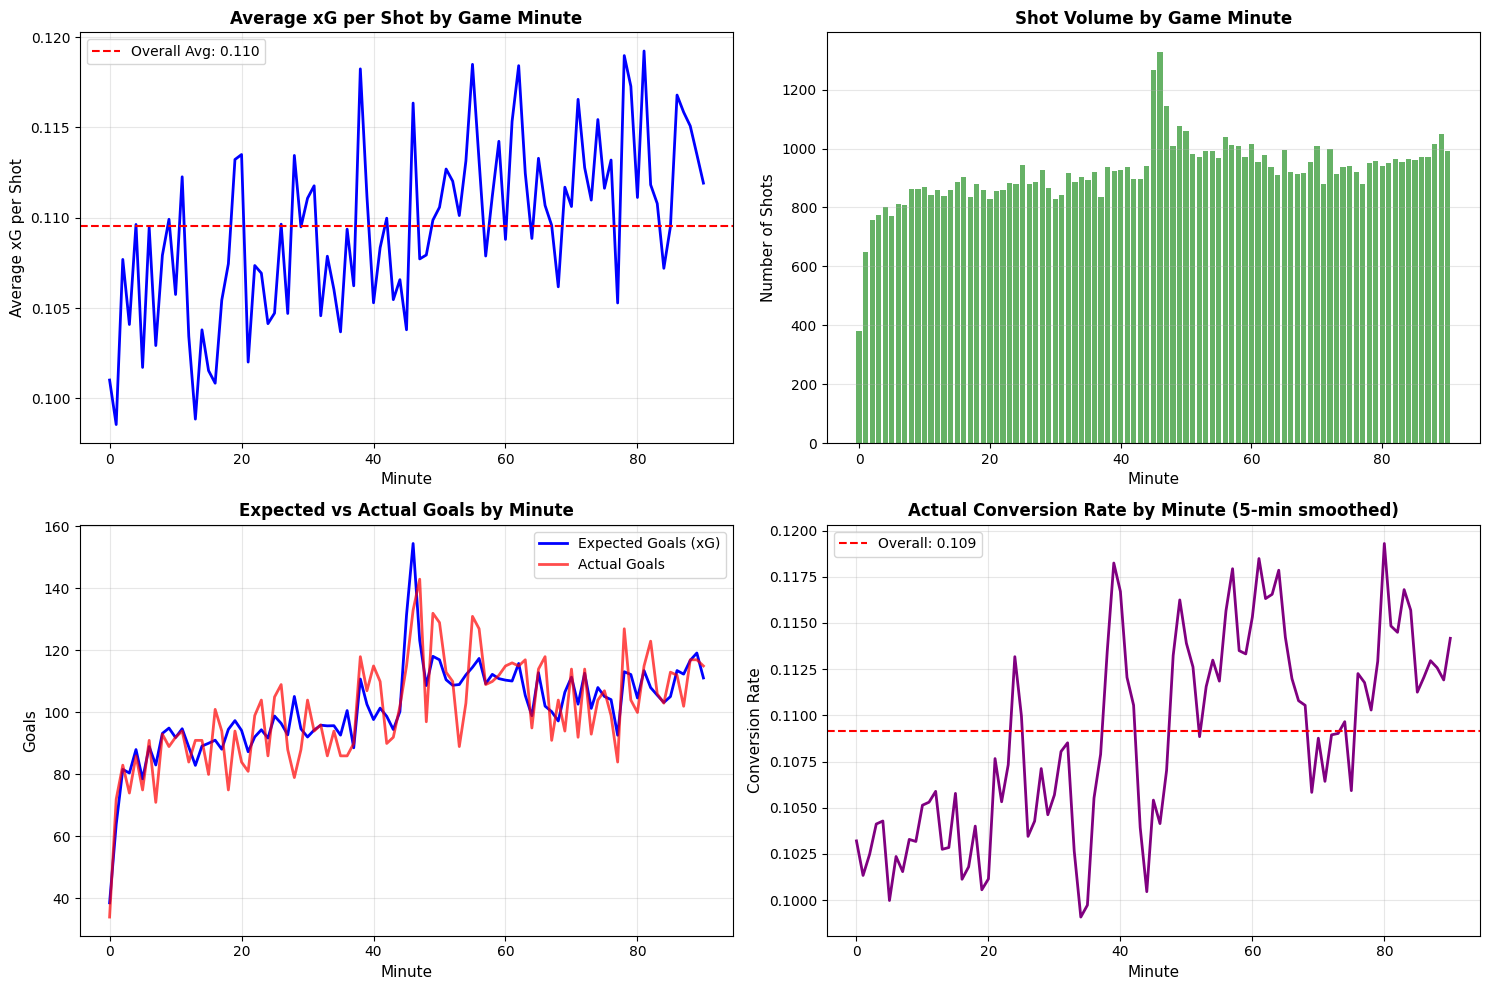


GAME PERIOD ANALYSIS
        Avg_xG   Total_xG  Actual_Goals  Conversion_Rate  Num_Shots  \
period                                                                
1-15    0.1051  1329.0117          1300           0.1028      12641   
16-30   0.1076  1410.9827          1391           0.1060      13118   
31-45   0.1078  1501.0213          1481           0.1064      13924   
46-60   0.1116  1736.9468          1753           0.1127      15559   
61-75   0.1123  1590.5966          1588           0.1121      14161   
76-90   0.1132  1635.3209          1637           0.1133      14444   

        xG_vs_Actual  
period                
1-15        -29.0117  
16-30       -19.9827  
31-45       -20.0213  
46-60        16.0532  
61-75        -2.5966  
76-90         1.6791  

Key Insights:
- Highest avg xG period: 76-90
- Highest conversion period: 76-90
- Most shots taken: 46-60
- Biggest overperformance: 46-60 (+16.05 goals)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming your dataframe is called 'shots_with_xg' and has these columns:
# minute, xG, shot_outcome

# 0. Filter to only regular time (0-90 minutes)
shots_with_xg = shots_with_xg[shots_with_xg['minute'] <= 90].copy()

# 1. Create a binary goal variable
shots_with_xg['is_goal'] = (shots_with_xg['shot_outcome'] == 'Goal').astype(int)

# 2. Group by minute and calculate metrics
minute_analysis = shots_with_xg.groupby('minute').agg({
    'xG': ['mean', 'sum', 'count'],  # avg xG, total xG, number of shots
    'is_goal': 'sum'  # actual goals scored
}).reset_index()

# Flatten column names
minute_analysis.columns = ['minute', 'avg_xG', 'total_xG', 'num_shots', 'actual_goals']

# 3. Calculate actual conversion rate per minute
minute_analysis['conversion_rate'] = minute_analysis['actual_goals'] / minute_analysis['num_shots']
minute_analysis['expected_goals'] = minute_analysis['avg_xG'] * minute_analysis['num_shots']

# 4. Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Average xG per minute
axes[0, 0].plot(minute_analysis['minute'], minute_analysis['avg_xG'], linewidth=2, color='blue')
axes[0, 0].set_xlabel('Minute', fontsize=11)
axes[0, 0].set_ylabel('Average xG per Shot', fontsize=11)
axes[0, 0].set_title('Average xG per Shot by Game Minute', fontsize=12, weight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=minute_analysis['avg_xG'].mean(), color='red', linestyle='--', 
                    label=f'Overall Avg: {minute_analysis["avg_xG"].mean():.3f}')
axes[0, 0].legend()

# Plot 2: Number of shots per minute
axes[0, 1].bar(minute_analysis['minute'], minute_analysis['num_shots'], color='green', alpha=0.6)
axes[0, 1].set_xlabel('Minute', fontsize=11)
axes[0, 1].set_ylabel('Number of Shots', fontsize=11)
axes[0, 1].set_title('Shot Volume by Game Minute', fontsize=12, weight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Expected vs Actual Goals per minute
axes[1, 0].plot(minute_analysis['minute'], minute_analysis['expected_goals'], 
                label='Expected Goals (xG)', linewidth=2, color='blue')
axes[1, 0].plot(minute_analysis['minute'], minute_analysis['actual_goals'], 
                label='Actual Goals', linewidth=2, color='red', alpha=0.7)
axes[1, 0].set_xlabel('Minute', fontsize=11)
axes[1, 0].set_ylabel('Goals', fontsize=11)
axes[1, 0].set_title('Expected vs Actual Goals by Minute', fontsize=12, weight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Conversion rate per minute (smoothed)
# Smooth with rolling average to reduce noise
minute_analysis['conversion_smooth'] = minute_analysis['conversion_rate'].rolling(
    window=5, center=True, min_periods=1).mean()

axes[1, 1].plot(minute_analysis['minute'], minute_analysis['conversion_smooth'], 
                linewidth=2, color='purple')
axes[1, 1].set_xlabel('Minute', fontsize=11)
axes[1, 1].set_ylabel('Conversion Rate', fontsize=11)
axes[1, 1].set_title('Actual Conversion Rate by Minute (5-min smoothed)', fontsize=12, weight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=shots_with_xg['is_goal'].mean(), color='red', linestyle='--', 
                    label=f'Overall: {shots_with_xg["is_goal"].mean():.3f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 5. Print summary statistics by period
print("\n" + "="*60)
print("GAME PERIOD ANALYSIS")
print("="*60)

# Create period bins (right=True means bins are (a, b], so 0-15 means 0 < x <= 15)
shots_with_xg['period'] = pd.cut(shots_with_xg['minute'], 
                      bins=[0, 15, 30, 45, 60, 75, 90], 
                      labels=['1-15', '16-30', '31-45', '46-60', '61-75', '76-90'],
                      include_lowest=True)

period_summary = shots_with_xg.groupby('period', observed=True).agg({
    'xG': ['mean', 'sum'],
    'is_goal': ['sum', 'mean'],
    'shot_outcome': 'count'
}).round(4)

period_summary.columns = ['Avg_xG', 'Total_xG', 'Actual_Goals', 'Conversion_Rate', 'Num_Shots']
period_summary['xG_vs_Actual'] = period_summary['Actual_Goals'] - period_summary['Total_xG']

print(period_summary)
print("="*60)
print("\nKey Insights:")
print(f"- Highest avg xG period: {period_summary['Avg_xG'].idxmax()}")
print(f"- Highest conversion period: {period_summary['Conversion_Rate'].idxmax()}")
print(f"- Most shots taken: {period_summary['Num_Shots'].idxmax()}")
print(f"- Biggest overperformance: {period_summary['xG_vs_Actual'].idxmax()} "
      f"(+{period_summary['xG_vs_Actual'].max():.2f} goals)")